# Dependencies and Data

In [74]:
# Dependencies
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [75]:
# Load Data
path = "C:\\Users\\sonla\\Documents\\EnergyPrices\\Data\\train.csv"
data = pd.read_csv(path)
data.head()

,Date_Begin_Local,T2M_AVG,WS50M_AVG,RH2M_AVG,GHI_AVG,price_lag_1,price_lag_24,price_lag_168,AIL_lag_1,AIL_lag_24,...,is_high_wind,is_solar_generating,is_chinook,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2020-01-08 00:00:00,-6.500000,9.153333,95.103333,0.0,27.15,34.48,30.24,10061.0,9932.0,...,0,0,0,0.10,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
1,2020-01-08 01:00:00,-6.256667,9.803333,95.253333,0.0,27.25,32.97,29.43,9869.0,9827.0,...,0,0,0,-0.62,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2,2020-01-08 02:00:00,-6.096667,9.913333,95.220000,0.0,26.63,35.64,29.66,9728.0,9773.0,...,0,0,0,-1.22,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025
3,2020-01-08 03:00:00,-6.336667,9.323333,95.933333,0.0,25.41,35.60,28.19,9676.0,9749.0,...,0,0,0,1.52,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025
4,2020-01-08 04:00:00,-6.606667,9.123333,95.936667,0.0,26.93,37.01,31.17,9727.0,9825.0,...,0,0,0,1.09,0.866025,0.500000,0.974928,-0.222521,0.5,0.866025


# Prepare Dataset for training

In [76]:
# Drop Unnecessary Columns
data = data.drop(columns=["Date_Begin_Local"])

# Extract target variable
X = data.drop(columns=["delta_price"])
y = data["delta_price"]

# Train-Validation Split
split =0.8
split_index = int(len(X) * split)
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

# Train LSTM Model

## 1. Helper classes and functions

In [77]:
# Time series loader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, lookback):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        X_seq = self.X[idx : idx + self.lookback]
        y_seq = self.y[idx + self.lookback]
        return X_seq, y_seq
    
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)
        lstm_out = self.fc(lstm_out)
        return lstm_out.squeeze(-1)
    
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return self.counter >= self.patience
    
# Feature Scaling
scaler = StandardScaler()


## 2. Model SETUP

In [78]:
# Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Hyperparameters
LOOKBACK = 48
BATCHSIZE = 32
INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001

# Create datasets
train_dataset = TimeSeriesDataset(X_train_scaled, y_train, LOOKBACK)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val, LOOKBACK)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCHSIZE, shuffle=False)

# Initialize model, loss function, and optimizer
model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
loss_function = nn.HuberLoss(delta=10.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# SETUP Logs:
print(f"Train sequences : {len(train_dataset)}")
print(f"Validation sequences : {len(val_dataset)}")
print(f"Sequence shape  : ({LOOKBACK}, {X_train_scaled.shape[1]})")
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Train sequences : 31159
Validation sequences : 7754
Sequence shape  : (48, 25)
LSTMModel(
  (lstm): LSTM(25, 32, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable params: 16,033


## 3. LSTM Training

In [79]:
train_losses = []
val_losses = []
EPOCHS = 150

early_stopping = EarlyStopping(patience=15, min_delta=0)

for epoch in range(EPOCHS):
    # Training Pass -----
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        fw_pass_outputs = model(X_batch)
        # Compute loss
        loss = loss_function(fw_pass_outputs, y_batch)
        # Backward pass
        loss.backward()
        # Gradient clipping (Keep gradients in check)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Update weights
        optimizer.step()
        # Accumulate loss
        epoch_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Pass -----
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_pass_outputs = model(X_batch)
            loss = loss_function(val_pass_outputs, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    if early_stopping(epoch_val_loss, model):
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)
    print(f"Best val loss: {early_stopping.best_loss:.4f}")
else:
    print("Warning: no best state saved.")

Epoch 1/150 - Train Loss: 306.2155 - Val Loss: 277.1520
Epoch 2/150 - Train Loss: 305.0475 - Val Loss: 274.9914
Epoch 3/150 - Train Loss: 303.3749 - Val Loss: 272.9673
Epoch 4/150 - Train Loss: 301.8190 - Val Loss: 271.2277
Epoch 5/150 - Train Loss: 300.3148 - Val Loss: 269.4624
Epoch 6/150 - Train Loss: 298.9614 - Val Loss: 268.4250
Epoch 7/150 - Train Loss: 297.4755 - Val Loss: 267.0798
Epoch 8/150 - Train Loss: 296.5785 - Val Loss: 266.4688
Epoch 9/150 - Train Loss: 295.5145 - Val Loss: 265.6595
Epoch 10/150 - Train Loss: 294.6925 - Val Loss: 265.3134
Epoch 11/150 - Train Loss: 293.8108 - Val Loss: 264.6687
Epoch 12/150 - Train Loss: 293.1769 - Val Loss: 264.1988
Epoch 13/150 - Train Loss: 292.0483 - Val Loss: 262.9401
Epoch 14/150 - Train Loss: 291.4620 - Val Loss: 263.1600
Epoch 15/150 - Train Loss: 290.8399 - Val Loss: 263.3929
Epoch 16/150 - Train Loss: 289.8643 - Val Loss: 263.2404
Epoch 17/150 - Train Loss: 289.1067 - Val Loss: 262.3504
Epoch 18/150 - Train Loss: 288.1760 - Va

## 4. Model Validation Eval

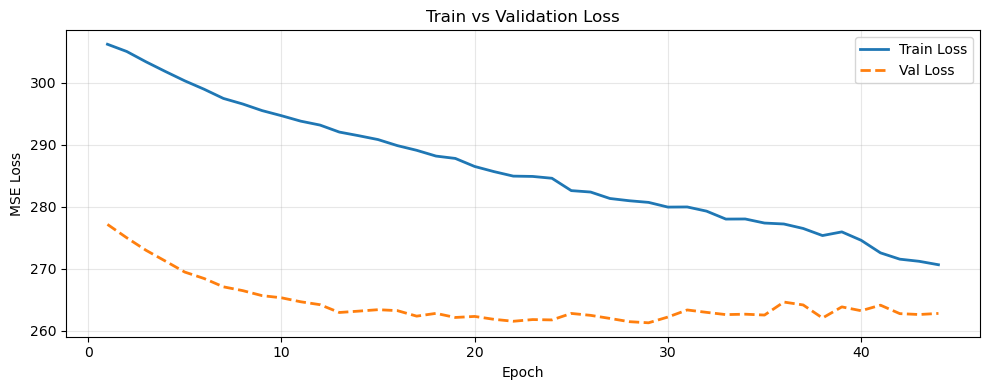

   Validation Metrics
  MSE:    261.2773 $/MWh²
  RMSE:    67.7333 $/MWh
  MAE:     29.5808 $/MWh
   Naive Baseline Metrics
Naive MAE:  31.2402 $/MWh
Naive RMSE: 73.0483 $/MWh


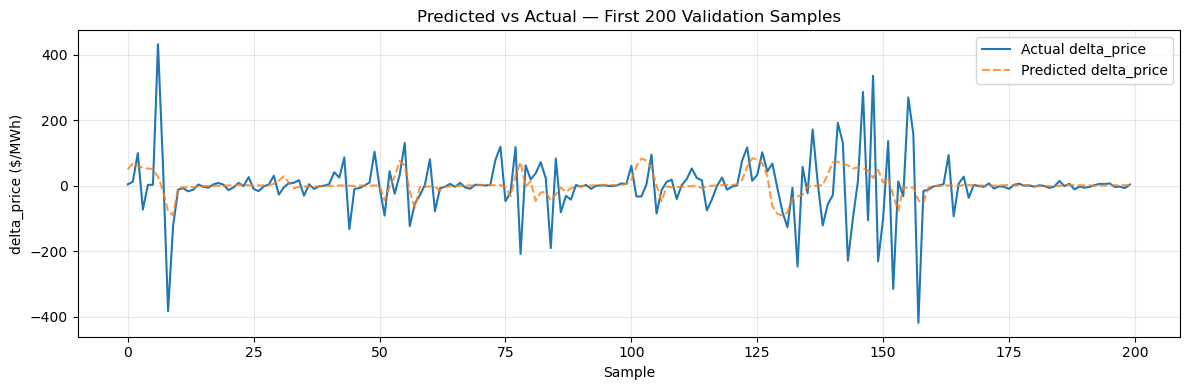

In [80]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# ── 1. Train vs Val Loss Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_ran = range(1, len(train_losses) + 1)

ax.plot(epochs_ran, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_ran, val_losses,   label="Val Loss",   linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Collect predictions on validation set ─────────────────────────────
model.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch)
        all_preds.extend(preds.numpy())
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# ── 3. RMSE ──────────────────────────────────────────────────────────────
rmse = mean_squared_error(all_targets, all_preds) ** 0.5
mae = mean_absolute_error(all_targets, all_preds)

# ── 4. Print metrics ─────────────────────────────────────────────────────
print("=" * 40)
print("   Validation Metrics")
print("=" * 40)
print(f"  MSE:  {early_stopping.best_loss:>10.4f} $/MWh²")
print(f"  RMSE: {rmse:>10.4f} $/MWh")
print(f"  MAE:  {mae:>10.4f} $/MWh")
print("=" * 40)
# Naive baseline: delta_price = 0 (predict no change)
naive_mae  = np.mean(np.abs(all_targets))
naive_rmse = np.std(all_targets)
print("=" * 40)
print("   Naive Baseline Metrics")
print("=" * 40)
print(f"Naive MAE:  {naive_mae:.4f} $/MWh")
print(f"Naive RMSE: {naive_rmse:.4f} $/MWh")
print("=" * 40)
# ── 5. Predicted vs Actual plot (first 200 samples) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_targets[:200], label="Actual delta_price",    linewidth=1.5)
ax.plot(all_preds[:200],   label="Predicted delta_price", linewidth=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("Sample")
ax.set_ylabel("delta_price ($/MWh)")
ax.set_title("Predicted vs Actual — First 200 Validation Samples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()